## Prepare samples for chip order
- Author: Linna An
- version: 2021, Feb 7th
- Acknowledge: Chris Norn, Gyu Rie Lee
- 1. This notebook prepared for samples which require 2-piece assembly
- 2. Material: all pdbs for order
- 3. Rough Steps:
    1. pdbs will be translated into amino acid sequences
    2. aa sequences will be sorted into different subpools (1000 sequence each) based on length
    3. Within each subpool, sequences will be pad to the same length
    4. Each subpool will be translated to DNA sequences
    5. Each translated subpool will be added with required adaptors
    6. Each prepared subpool will be measured for its overlap diversity

In [1]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
import os, subprocess, glob, re, gzip, math, shutil, itertools, sys, time, math, string
from shutil import copyfile
from numpy import *
from numpy import linalg
sys.path.append('/u/project/jzz0428/shared/software/lib')
#from libSlurm_public import make_submit_file #version not containing email alert
#from libSlurm_public import make_dist_plots

from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
from IPython.display import IFrame

/tmp/ipykernel_19200/32642923.py:15: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


- Provide directory containing all directories storing all pdbs to order

In [2]:
PARENT_DIR = '/u/home/c/cchen88/test/pY1045_run2_hb3_1479'
os.chdir(PARENT_DIR)
%pwd

'/u/home/c/cchen88/test/pY1045_run2_hb3_1479'

### Option1: Translate designs from pdb to sequences

In [2]:
def translate(pdb):
    PDB2SEQ = '/u/home/c/cchen88/test/pY1045_run1_hb2_97/pY1045_binder_seq.fasta'
    result = subprocess.run([PDB2SEQ,pdb], stdout=subprocess.PIPE)
    aa_seq = result.stdout.decode('utf-8').rstrip()
    aa_length = len(aa_seq)
    return aa_seq, aa_length

- Go through each sub-directory, translate all designs into pdb sequences, and save in a single file

In [6]:
# pdb_list = []
# for num,pdb in enumerate(glob.glob(f'{PARENT_DIR}/*/*.pdb')):
#     aa_seq, aa_length = translate(pdb)
#     pdb_list.append([pdb,aa_seq,aa_length])
# df = pd.DataFrame(pdb_list,columns=['design','seq','length'])
# print(len(df))
#sc_f = '/u/home/c/cchen88/test/pY1045_run1_hb2_97/output.seq'
#df = pd.read_csv(sc_f,delim_whitespace=True,names=['design','seq'])
#df['length']=df['seq'].str.len()
#df

/tmp/ipykernel_14552/1671795038.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(sc_f,delim_whitespace=True,names=['design','seq'])


,design,seq,length
0,design,seq,3.0
1,formpnn_test_ptmsidpc_10_198-atomized-bb-False...,KTLVRHVAAHPDPALADKVLIPVTAESADIALYTHELARELGIETV...,147.0
2,formpnn_test_ptmsidpc_10_198-atomized-bb-False...,VTLNLYYKPHPDPALADKVIIHTTAENADIAIELAETADELGIDYV...,147.0
3,formpnn_test_ptmsidpc_10_198-atomized-bb-False...,KTLVRFLAPHPDPRYRDKVVIEVDYEDVDIAIYTARVAKKLGIDFI...,147.0
4,formpnn_test_ptmsidpc_10_198-atomized-bb-False...,KTLVRHLAPHPDPEFRDKVVIEVNEEDVDIAIYTARVAEELGIDFV...,147.0
...,...,...,...
93,formpnn_test_ptmsidpc_9_849-atomized-bb-False_...,SERFVKELKENAKKNAAKLPPASSAENAELLIEDYRAETARALEAL...,142.0
94,formpnn_test_ptmsidpc_9_859-atomized-bb-False_...,APQLKRVTAADYRAGAEQAEAEGALNLALDWREYADYLEAKGAAAG...,158.0
95,formpnn_test_ptmsidpc_9_859-atomized-bb-False_...,TPQIKINTAADYRAGAEQARAEGAENLALDWSNHADYLERKGEAAG...,158.0
96,formpnn_test_ptmsidpc_9_929-atomized-bb-False_...,LDEKVKENLRREQEILDRFRDPAHRAELVAQLGKDYLVDNVLYLED...,160.0


In [3]:
sc_f = '/u/home/c/cchen88/test/pY1045_run2_hb3_1479/output.seq'
df = pd.read_csv(sc_f, sep='\t')
df['length'] = df['seq'].str.len()
df

,design,seq,length
0,formpnn_test_ptmsidpc_10_198-atomized-bb-False...,KVLELHYVRHPDPALADKVIIYVTADDAAEAVEKARIADRLGIDYV...,147.0
1,formpnn_test_ptmsidpc_10_198-atomized-bb-False...,KVLVLLVLPHPDPALADKVVIHVTADTGAIAIYLAKLADELGIPYV...,147.0
2,formpnn_test_ptmsidpc_10_198-atomized-bb-False...,KTLVLYVLPHPDPALRDKVVIPVDAATGDLAIFLADVADKLGIPYI...,147.0
3,formpnn_test_ptmsidpc_10_198-atomized-bb-False...,KRLELFYIRHPDPEFADKVVIEVTADDGAEAIERAKVADELGIDYI...,147.0
4,formpnn_test_ptmsidpc_10_198-atomized-bb-False...,RTLKLYLAPHPDPAYRDKVVILVREDTTEISVYIARVADRLGIPYI...,147.0
...,...,...,...
1474,formpnn_test_ptmsidpc_9_973-atomized-bb-False_...,DDRARIRVAATNFVIIQGIREYNRRRGTEVTAEQREILAENTRLAA...,155.0
1475,formpnn_test_ptmsidpc_9_973-atomized-bb-False_...,DRATQFRVAATNHVIINGIREYNRRRGTEVTEEQKEILATATKLAA...,155.0
1476,formpnn_test_ptmsidpc_9_973-atomized-bb-False_...,GDLDKIRVAAQNYVIRRGIREYNRRRGTAVTAEQLALSRLVYELAK...,155.0
1477,formpnn_test_ptmsidpc_9_973-atomized-bb-False_...,GTDTDEYTAALNFIIIRGIREYNRERGTEVTAEQIEILKTATERAK...,155.0


In [4]:
df.tail()

,design,seq,length
1474,formpnn_test_ptmsidpc_9_973-atomized-bb-False_...,DDRARIRVAATNFVIIQGIREYNRRRGTEVTAEQREILAENTRLAA...,155.0
1475,formpnn_test_ptmsidpc_9_973-atomized-bb-False_...,DRATQFRVAATNHVIINGIREYNRRRGTEVTEEQKEILATATKLAA...,155.0
1476,formpnn_test_ptmsidpc_9_973-atomized-bb-False_...,GDLDKIRVAAQNYVIRRGIREYNRRRGTAVTAEQLALSRLVYELAK...,155.0
1477,formpnn_test_ptmsidpc_9_973-atomized-bb-False_...,GTDTDEYTAALNFIIIRGIREYNRERGTEVTAEQIEILKTATERAK...,155.0
1478,formpnn_test_ptmsidpc_9_973-atomized-bb-False_...,DDRQKIRVAAQNYVIRRGIREYNRRRGTAVTAEQLELAQTVYDLAK...,155.0


In [5]:
df.to_csv('./all_pdb')

In [6]:
#remove duplicate
df = pd.read_csv('all_pdb')
df = df.drop_duplicates(subset='seq')
print(len(df))
df.to_csv('./all_pdb_nonredundant')
print(len(df))
df

1451
1451


,Unnamed: 0,design,seq,length
0,0,formpnn_test_ptmsidpc_10_198-atomized-bb-False...,KVLELHYVRHPDPALADKVIIYVTADDAAEAVEKARIADRLGIDYV...,147.0
1,1,formpnn_test_ptmsidpc_10_198-atomized-bb-False...,KVLVLLVLPHPDPALADKVVIHVTADTGAIAIYLAKLADELGIPYV...,147.0
2,2,formpnn_test_ptmsidpc_10_198-atomized-bb-False...,KTLVLYVLPHPDPALRDKVVIPVDAATGDLAIFLADVADKLGIPYI...,147.0
3,3,formpnn_test_ptmsidpc_10_198-atomized-bb-False...,KRLELFYIRHPDPEFADKVVIEVTADDGAEAIERAKVADELGIDYI...,147.0
4,4,formpnn_test_ptmsidpc_10_198-atomized-bb-False...,RTLKLYLAPHPDPAYRDKVVILVREDTTEISVYIARVADRLGIPYI...,147.0
...,...,...,...,...
1474,1474,formpnn_test_ptmsidpc_9_973-atomized-bb-False_...,DDRARIRVAATNFVIIQGIREYNRRRGTEVTAEQREILAENTRLAA...,155.0
1475,1475,formpnn_test_ptmsidpc_9_973-atomized-bb-False_...,DRATQFRVAATNHVIINGIREYNRRRGTEVTEEQKEILATATKLAA...,155.0
1476,1476,formpnn_test_ptmsidpc_9_973-atomized-bb-False_...,GDLDKIRVAAQNYVIRRGIREYNRRRGTAVTAEQLALSRLVYELAK...,155.0
1477,1477,formpnn_test_ptmsidpc_9_973-atomized-bb-False_...,GTDTDEYTAALNFIIIRGIREYNRERGTEVTAEQIEILKTATERAK...,155.0


### Separate those shorter than 120 aa and those longer

In [15]:
df_230nt = pd.DataFrame()
df_230nt = df[df['length'] <= 120]
print(len(df_230nt))
df_230nt.to_csv('all_pdb_nonredundant_120aa')

12


In [20]:
df_250nt = pd.DataFrame()
df_250nt = df[df['length'] > 120 ]
df_250nt.to_csv(sc_f + '_250nt')

In [24]:
for num,pdb in enumerate(glob.glob('./filtered_binder_designs/*.pdb')):
    if pdb not in list(df['design']):
         subprocess.check_call(f'rm {pdb}',shell=True)
pdb_list = glob.glob('./filtered_binder_designs/*.pdb')
print(f'After remove redundant sequences, left {len(pdb_list)}.')
print(f'230nt {len(df_230nt)}\n300nt {len(df_300nt)}')

After remove redundant sequences, left 0.


NameError: name 'df_300nt' is not defined

In [ ]:
# df_300nt = pd.read_csv('./all_pdb_nonredundant_300nt')
# df_300nt

### Option2: Read from a file

In [ ]:
start_f = './all_pdb_nonredundant'
df = pd.read_csv(start_f)
print(f'This file contains {len(df)} oligos')
#remove duplicate
df = df.drop_duplicates(subset='seq')
print(f'after remove redundent {len(df)}')
df.to_csv(start_f + '_nonredundant')

### Separate those shorter than 120 aa and those longer

In [ ]:
# df_230nt = pd.DataFrame()
# df_230nt = df[df['length'] <= 120]
# df_230nt.to_csv('all_pdb_nonredundant_230nt')
# print(len(df_230nt))

In [ ]:
# df_300nt = pd.DataFrame()
# df_300nt = df[df['length'] > 120]
# df_300nt.to_csv(start_f + '_250nt')

In [ ]:
# print(f'230nt {len(df_230nt)}\n300nt {len(df_300nt)}')

In [ ]:
# df_300nt = pd.read_csv(start_f + '_250nt')
# df_300nt


## Chose a subset since the total design number is way bigger than my quota

In [ ]:
# print(len(df_300nt))

In [ ]:
# df_sel_C2F = df_300nt[df_300nt['design'].str.contains('C2F')]
# df_sel_C2F = df_sel_C2F.drop_duplicates(subset='seq')
# df_sel_C2F.to_csv('./C2F_all_pdb_nonredundant_250nt')
# # df_sel_THG = df_300nt[df_300nt['design'].str.contains('THG')]
# # df_sel_THG.to_csv('./THG_all_pdb_nonredundant_300nt')
# # df_sel_order = pd.concat([df_sel_FOL,df_sel_THG])
# # print(len(df_sel))
# print(len(df_sel_C2F))
# # df_sel_order
# # df_sel_order.to_csv('./210402_twist_order_FOL_THG')

### Double check if pdb2seq made any mistake | possible to happen if there is an unnatural aa, pdb2seq just skips it

In [7]:
def get_length(pdb):
    fp = open(pdb,'r')
    length = 0
    for line in fp:
        if line.rstrip != '':
            if line.startswith('ATOM'):
                res = int(line[22:26])
                if res > length:
                    length = res
    fp.close()
    return length

In [8]:
df = pd.read_csv('all_pdb_nonredundant') # Chose which ones to convert
print(f'Total number {len(df)}')
df.head()

Total number 1451


,Unnamed: 0.1,Unnamed: 0,design,seq,length
0,0,0,formpnn_test_ptmsidpc_10_198-atomized-bb-False...,KVLELHYVRHPDPALADKVIIYVTADDAAEAVEKARIADRLGIDYV...,147.0
1,1,1,formpnn_test_ptmsidpc_10_198-atomized-bb-False...,KVLVLLVLPHPDPALADKVVIHVTADTGAIAIYLAKLADELGIPYV...,147.0
2,2,2,formpnn_test_ptmsidpc_10_198-atomized-bb-False...,KTLVLYVLPHPDPALRDKVVIPVDAATGDLAIFLADVADKLGIPYI...,147.0
3,3,3,formpnn_test_ptmsidpc_10_198-atomized-bb-False...,KRLELFYIRHPDPEFADKVVIEVTADDGAEAIERAKVADELGIDYI...,147.0
4,4,4,formpnn_test_ptmsidpc_10_198-atomized-bb-False...,RTLKLYLAPHPDPAYRDKVVILVREDTTEISVYIARVADRLGIPYI...,147.0


In [8]:
error_list = []
for design in list(df['design']):
    pdb_length = get_length(design)
    aa_length = int(df.loc[df['design'] == design]['length'].to_string(index = False))
    if pdb_length != aa_length:
        error_list.append(design)
        print(f'!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!\n BAD: {design} is okay, length is {aa_length} equals to {pdb_length}')
#     elif pdb_length == aa_length:
#         print(f'Good: {design} is okay, length is {aa_length} equals to {pdb_length}')
print(f'In total potential error number: {len(error_list)}')

FileNotFoundError: [Errno 2] No such file or directory: 'formpnn_test_ptmsidpc_10_198-atomized-bb-False_5_1_pb1_h'

In [ ]:
# for num,pdb in enumerate(glob.glob('./*/*.pdb')):
#     if pdb not in list(df['design']):
#         subprocess.check_call(f'rm {pdb}',shell=True)
# pdb_list = glob.glob('./*/*.pdb')
# print(f'After remove redundant sequences, left {len(pdb_list)}.')

### Split to different subpools

In [4]:
# change order based on length
df = df.sort_values(by='length',ascending=True)
print(len(df))
df

1479


,design,seq,length
647,formpnn_test_ptmsidpc_14_196-atomized-bb-False...,GILSDEAVVRSRGVSTGVARAVGGAPAYVERLLAADRAATPAEDQA...,93.0
645,formpnn_test_ptmsidpc_14_196-atomized-bb-False...,KILTDEAVIRARGVSVGVARALGAAPAYVARLEARAVAETPAEDQP...,93.0
646,formpnn_test_ptmsidpc_14_196-atomized-bb-False...,KILSDEAVIRSRGVALGVARALGAAPAYLARLEAEDRGRTPEEDLP...,93.0
1136,formpnn_test_ptmsidpc_9_517-atomized-bb-False_...,DPVQEALKEIAEEAIKLIKKLPTEEAKQRAYEELLKLREHYLRAVA...,94.0
177,formpnn_test_ptmsidpc_10_984-atomized-bb-False...,RPITRGERYVYYVYPELAAADPRTKTYAAELDEFRALLDAVYEKVA...,102.0
...,...,...,...
885,formpnn_test_ptmsidpc_14_766-atomized-bb-False...,NaN,NaN
895,formpnn_test_ptmsidpc_14_766-atomized-bb-False...,NaN,NaN
899,formpnn_test_ptmsidpc_14_766-atomized-bb-False...,NaN,NaN
999,formpnn_test_ptmsidpc_8_304-atomized-bb-False_...,NaN,NaN


In [10]:
df = df.dropna(subset=['seq', 'length'])
df.to_csv('output_clean.csv', index=False)
df

,Unnamed: 0.1,Unnamed: 0,design,seq,length
635,647,647,formpnn_test_ptmsidpc_14_196-atomized-bb-False...,GILSDEAVVRSRGVSTGVARAVGGAPAYVERLLAADRAATPAEDQA...,93.0
633,645,645,formpnn_test_ptmsidpc_14_196-atomized-bb-False...,KILTDEAVIRARGVSVGVARALGAAPAYVARLEARAVAETPAEDQP...,93.0
634,646,646,formpnn_test_ptmsidpc_14_196-atomized-bb-False...,KILSDEAVIRSRGVALGVARALGAAPAYLARLEAEDRGRTPEEDLP...,93.0
1108,1136,1136,formpnn_test_ptmsidpc_9_517-atomized-bb-False_...,DPVQEALKEIAEEAIKLIKKLPTEEAKQRAYEELLKLREHYLRAVA...,94.0
174,177,177,formpnn_test_ptmsidpc_10_984-atomized-bb-False...,RPITRGERYVYYVYPELAAADPRTKTYAAELDEFRALLDAVYEKVA...,102.0
...,...,...,...,...,...
902,928,928,formpnn_test_ptmsidpc_14_766-atomized-bb-False...,QSIDLIYYFRVDPALTPEELARIFAEFGARHRAERLKYGPAYRNFI...,160.0
901,927,927,formpnn_test_ptmsidpc_14_766-atomized-bb-False...,ASVDIIYYFTVDPALSPEQLARVFADLGREHREVRLKYYDAYKNFL...,160.0
900,926,926,formpnn_test_ptmsidpc_14_766-atomized-bb-False...,ASVDIIRYFEVDPALTPEQLAQIYVDFGQANRELRLKYQSAYTNLL...,160.0
899,925,925,formpnn_test_ptmsidpc_14_766-atomized-bb-False...,SSINIIRYYEFDPSLTPEQVAEIYWRWGQENRELRLKYYDAYKNFL...,160.0


### decide subpools based on total length and legth distribution
- each subpool (aka oligos with the same adaptors) should less than 1000 oligos. To many oligos will decrease assembly effciency.
- the smaller each pool, the better, but don't do too small, since it will take long time PCR to enrich your libraries.

In [11]:
def merge_length(df_in):
    '''
    pad all sequences in each subpool to the same length as the max of the design in that subpool
    '''
    linker = 'GGSSGGSSGGSSGGSSGGSSGGSSG'

    df_in = df_in.copy()
    df_in['length'] = df_in['length'].astype(int)

    max_length = int(df_in['length'].max())

    for num in range(len(df_in)):
        length = int(df_in.loc[num, 'length'])
        if length != max_length:
            orig_seq = df_in.loc[num, 'seq']
            pad_len = max_length - length
            repeat_linker = (linker * ((pad_len // len(linker)) + 1))[:pad_len]
            new_seq = orig_seq + repeat_linker
            df_in.loc[num, 'seq'] = new_seq
            df_in.loc[num, 'length'] = len(new_seq)

    return df_in

<Axes: xlabel='length', ylabel='Count'>

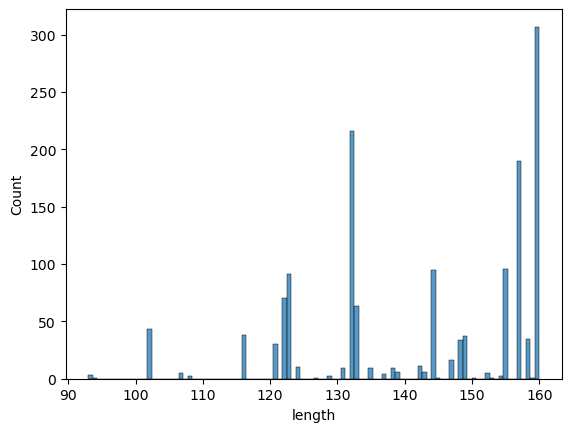

In [12]:
# #check aa length distribution
# make_dist_plots(df,['length'])
sns.histplot(data=df, x='length',bins=100)

In [3]:
## smart way to splite group
#1. split evenly; 2. move item from previous group to next, check if difference change; 3. move till difference not decrease
# https://stackoverflow.com/questions/69594124/divide-list-into-groups-based-on-adjoining-difference-values

from sklearn.cluster import AgglomerativeClustering
from sklearn import metrics
from scipy.cluster.hierarchy import dendrogram
import sklearn as sk


from sklearn.cluster import KMeans
import sklearn.metrics as sm
import math

In [14]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering

def smart_splite(length_list, N=None, min_num=300, max_num=1000):
    '''
    1. generate distance matrix
    2. cluster matrix
    3. trace back to items
    '''
    length_list = list(length_list)

    if N is None:
        N = int(len(length_list) / 1000) + 1

    print(f'N {N}')

    dif_lists = []
    for i in length_list:
        single_line_diff = []
        for j in length_list:
            single_line_diff.append(abs(j - i))
        dif_lists.append(single_line_diff)

    dif_mtx = np.array(dif_lists, dtype=float)

    ClustObj = AgglomerativeClustering(
        metric='precomputed',
        linkage='average',
        n_clusters=N
    )
    clustering = ClustObj.fit(dif_mtx)

    s = []
    clu = []

    for l, v in enumerate(sorted(set(clustering.labels_))):
        grp = np.sum(clustering.labels_ == v)
        print(f'grp{l}:{grp}', end=',')

        sub_dif = dif_mtx[clustering.labels_ == v][:, clustering.labels_ == v]
        clu.append(np.where(clustering.labels_ == v)[0])

        if grp > 1:
            iu = np.triu_indices(grp, 1)
            s.append(np.mean(sub_dif[iu]))
            print(f'item in cluster {len(clu[l])}, diff {max(sub_dif[iu]) - min(sub_dif[iu])}, {sub_dif[iu]}')
        else:
            s.append(0)
            print(f'item in cluster {len(clu[l])}')

    clu.sort(key=lambda x: x[0], reverse=False)

    id_list = []
    for indi_clu in clu:
        id_list.append([indi_clu[0], indi_clu[-1] + 1])

    return id_list

In [15]:
def check_id(df,id_list,ncols=5):
    nrows = math.ceil(len(id_list)/ ncols) #because we will also be plotting ROCs  
    (fig, axs) = plt.subplots(  
        ncols=ncols, nrows=nrows, figsize=[4*ncols,3*nrows]  
    )  
    axs = axs.reshape(-1)  
    for i,indi_id in enumerate(id_list):
        indi_df = df.iloc[indi_id[0]:indi_id[-1],:]
        sns.histplot(data=indi_df,x='length',bins=100,ax=axs[i],
            label=f'start_id {indi_id[0]}, end_id {indi_id[-1]},\n'+\
                  f'diff {max(list(indi_df.length))-min(list(indi_df.length))},number {len(indi_df)}').set_xlim([70,250])
        axs[i].legend()

In [16]:
length_list = list(df['length'])
len(length_list)

1450

In [19]:
#import numpy as np
#from sklearn.cluster import AgglomerativeClustering

#dif_mtx = np.array([np.array(xi) for xi in dif_lists])
#ClustObj = AgglomerativeClustering(metric='precomputed', linkage='average', n_clusters=N)
#clustering = ClustObj.fit(dif_mtx)

In [26]:
for v in ['df', 'length_list', 'dif_lists', 'N']:
    print(v, v in globals())

df True
length_list True
dif_lists False
N False


N 10
grp0:300,item in cluster 300, diff 8.0, [2. 2. 4. ... 0. 0. 0.]
grp1:631,item in cluster 631, diff 6.0, [0. 1. 1. ... 0. 0. 0.]
grp2:94,item in cluster 94, diff 6.0, [0. 0. 0. ... 0. 1. 1.]
grp3:19,item in cluster 19, diff 2.0, [0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 0. 0. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 2. 2.
 2. 2. 2. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 0.
 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0.
 1. 1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 0.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0.]
grp4:113,item in cluster 113, diff 3.0, [0. 0. 0. ... 0. 1. 1.]
grp5:4,item in cluster 4, diff 1.0, [0. 0. 1. 0. 1. 1.]
grp6:38,item in cluster 38, diff 0.0, [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0

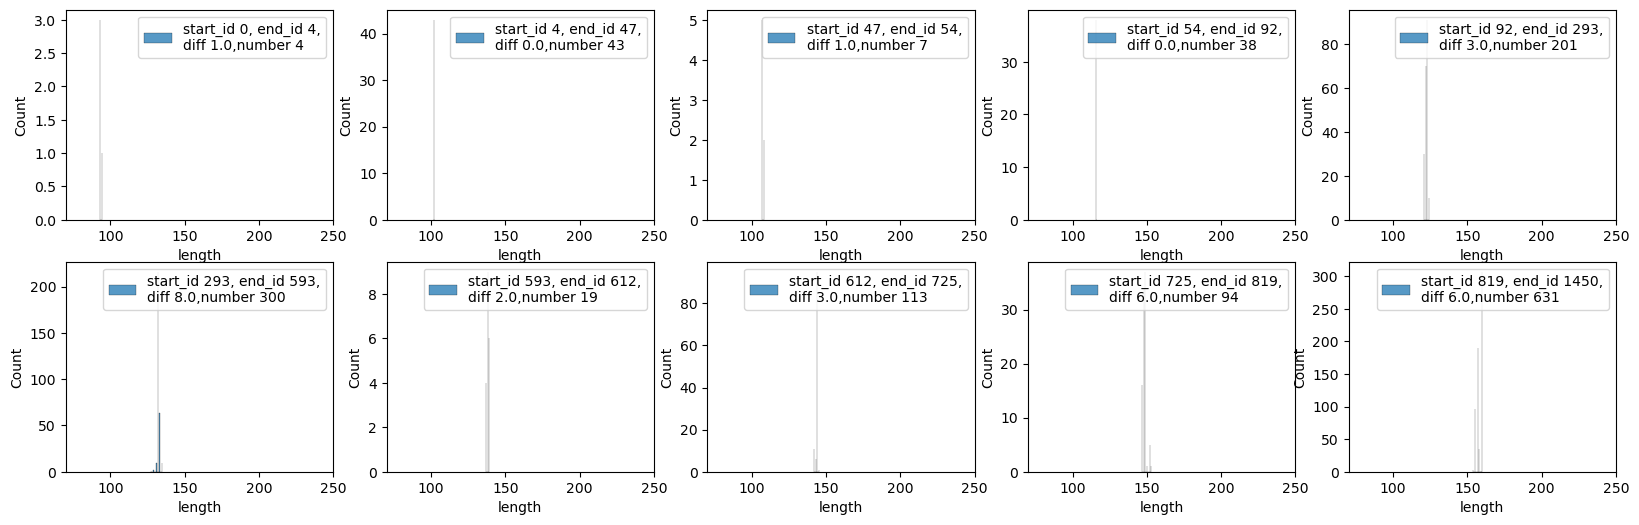

In [17]:
id_list = smart_splite(length_list,N=10)
#N here is the number of subgroup bins
check_id(df,id_list,ncols=5)

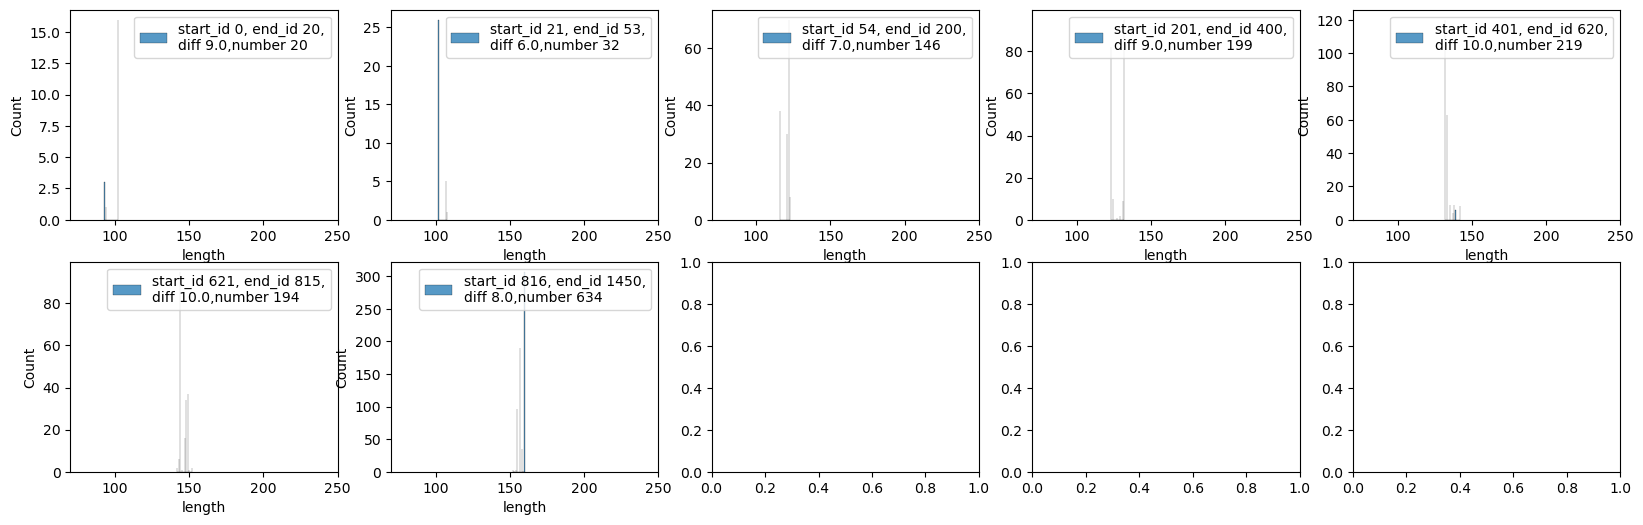

In [40]:
# manually create id_list based on smart split, make in group difference <= 10 aa
id_list = [[0,20],[21,53],[54,200], [201,400],[401,620],[621, 815],[816, 1450]] 
check_id(df,id_list,ncols=5)

In [41]:
# Decide subpool split and pad to longest sequence in each subpool
df_list = []
start = 0
for num,[start,end] in enumerate(id_list):
    print('--------process seq %s ~ %s ------'%(start,end))
    df_subpool = pd.DataFrame()
    df_subpool = df.iloc[start:end]
    print('subpool size: %d'%len(df_subpool))
    min_length,max_length = list(df_subpool['length'])[0],list(df_subpool['length'])[-1]
    print('Before padding: min %d max %d'%(min_length,max_length))
    df_subpool = df_subpool.reset_index()
    df_subpool = merge_length(df_subpool)
    df_subpool = df_subpool.sort_values(by='length',ascending=True)
    min_length,max_length = list(df_subpool['length'])[0],list(df_subpool['length'])[-1]
    print('after padding: min %d max %d'%(min_length,max_length))
    with open('subpool_{}'.format(num),'w') as fp:
        fp.write('\n'.join('%s %s'%(df_subpool.iloc[num].at['design'],df_subpool.iloc[num].at['seq']) for num in range(len(df_subpool))))
    start = end
#df_subpool.tail()
df_subpool

--------process seq 0 ~ 20 ------
subpool size: 20
Before padding: min 93 max 102
after padding: min 102 max 102
--------process seq 21 ~ 53 ------
subpool size: 32
Before padding: min 102 max 108
after padding: min 108 max 108
--------process seq 54 ~ 200 ------
subpool size: 146
Before padding: min 116 max 123
after padding: min 123 max 123
--------process seq 201 ~ 400 ------
subpool size: 199
Before padding: min 123 max 132
after padding: min 132 max 132
--------process seq 401 ~ 620 ------
subpool size: 219
Before padding: min 132 max 142
after padding: min 142 max 142
--------process seq 621 ~ 815 ------
subpool size: 194
Before padding: min 142 max 152
after padding: min 152 max 152
--------process seq 816 ~ 1450 ------
subpool size: 634
Before padding: min 152 max 160
after padding: min 160 max 160


,index,Unnamed: 0.1,Unnamed: 0,design,seq,length
623,879,905,905,formpnn_test_ptmsidpc_14_766-atomized-bb-False...,ASVDLIYYFEFDPSLTPEQIAAFYHDRGRRRRALQLQYQAAYQNFL...,160
622,1387,1415,1415,formpnn_test_ptmsidpc_9_929-atomized-bb-False_...,LEEEARKNLEREREYLEAWADPAHRADLVARLGEDPLVDRVLWEEE...,160
621,1388,1416,1416,formpnn_test_ptmsidpc_9_929-atomized-bb-False_...,LEKEAEANVERRLEYEEAWADPRHRRELADRLGEDPLIDNVLYNKE...,160
620,1389,1417,1417,formpnn_test_ptmsidpc_9_929-atomized-bb-False_...,LEAEAEANVEREAEYVARYRDPAHRLEIINLLGKDPLADRVLYNEE...,160
619,1390,1418,1418,formpnn_test_ptmsidpc_9_929-atomized-bb-False_...,LEEIADANVERELAYERAWADPAHRADLVAQLGRDPLVDRVLYLEE...,160
...,...,...,...,...,...,...
630,901,927,927,formpnn_test_ptmsidpc_14_766-atomized-bb-False...,ASVDIIYYFTVDPALSPEQLARVFADLGREHREVRLKYYDAYKNFL...,160
631,900,926,926,formpnn_test_ptmsidpc_14_766-atomized-bb-False...,ASVDIIRYFEVDPALTPEQLAQIYVDFGQANRELRLKYQSAYTNLL...,160
632,899,925,925,formpnn_test_ptmsidpc_14_766-atomized-bb-False...,SSINIIRYYEFDPSLTPEQVAEIYWRWGQENRELRLKYYDAYKNFL...,160
633,898,924,924,formpnn_test_ptmsidpc_14_766-atomized-bb-False...,KSVDIIRYFERDPALTPEQLAQIYYNRGIEKRELRLKYYDAYKNFL...,160


In [29]:
#print(len(df))
#for pair in id_list:
 #   start, end = pair
  #  print(pair, len(df.iloc[start:end, :]))

93
[0, 4] 4
[4, 15] 11
[15, 113] 78
[113, 199] 0
[199, 276] 0
[276, 377] 0
[377, 519] 0
[519, 853] 0
[853, 1209] 0


## Reverse transcribe
- Use the scripts from PPI

In [48]:
import os
import glob
import subprocess

#PARENT_DIR = '/u/home/c/cchen88/test/pY1045_run1_hb2_97'

for num, subpool in enumerate(sorted(glob.glob(PARENT_DIR + '/subpool_*'))):
    if subpool.endswith('_reverse_translate'):
        continue

    reverse_translate_dir = subpool + '_reverse_translate'
    os.makedirs(reverse_translate_dir, exist_ok=True)

    result = subprocess.run(
        [
            'python',
            '/u/home/c/cchen88/linna_DNAWorks/1_reverse_translate.py',
            '-seq_list',
            subpool
        ],
        cwd=reverse_translate_dir,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )

    print(f'processed {reverse_translate_dir}')
    if result.returncode != 0:
        print(result.stderr)

processed /u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_0_reverse_translate
processed /u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_1_reverse_translate
processed /u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_2_reverse_translate
processed /u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_3_reverse_translate
processed /u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_4_reverse_translate
processed /u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_5_reverse_translate
processed /u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_6_reverse_translate


In [49]:
import math

def make_qsub_file(cmds, submitfile, time="3:00:00", group_size=10, logsfolder='logs', cpus=1, mem='1G'):
    os.makedirs(logsfolder, exist_ok=True)

    with open(cmds) as f:
        n_jobs = sum(1 for line in f if line.strip())

    n_arrays = math.ceil(n_jobs / group_size)

    script = f"""#!/bin/bash
#$ -cwd
#$ -l h_rt={time},h_data={mem}
#$ -pe shared {cpus}
#$ -t 1-{n_arrays}
#$ -o {logsfolder}/out.$TASK_ID
#$ -e {logsfolder}/err.$TASK_ID

GROUP_SIZE={group_size}
CMD_FILE="{cmds}"

for I in $(seq 1 $GROUP_SIZE)
do
    J=$(( (SGE_TASK_ID - 1) * GROUP_SIZE + I ))
    CMD=$(sed -n "${{J}}p" "$CMD_FILE")
    [ -z "$CMD" ] && continue
    echo "Running task $J: $CMD"
    bash -lc "$CMD"
done
"""

    with open(submitfile, 'w') as f:
        f.write(script)

    return n_jobs, n_arrays

In [50]:
Submit = True

for num, subpool_dir in enumerate(sorted(glob.glob(PARENT_DIR + '/subpool_*_reverse_translate'))):
    cmds_f = os.path.join(subpool_dir, 'all_dnaworks.list')

    if not os.path.exists(cmds_f):
        print(f'skip missing {cmds_f}')
        continue

    os.makedirs(os.path.join(subpool_dir, 'logs'), exist_ok=True)

    submit_f = cmds_f + '.submit.sh'
    n_jobs, n_arrays = make_qsub_file(
        cmds=cmds_f,
        submitfile=submit_f,
        time="3:00:00",
        group_size=10,
        logsfolder=os.path.join(subpool_dir, 'logs'),
        cpus=1,
        mem='1G'
    )

    if Submit:
        subprocess.check_call(['qsub', submit_f], cwd=subpool_dir)
        print(f'submitted {subpool_dir} ({n_jobs} cmds, {n_arrays} array tasks)')

/tmp/ipykernel_5962/925386465.py:7: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  n_jobs = sum(1 for line in f if line.strip())


Your job-array 12762527.1-2:1 ("all_dnaworks.list.submit.sh") has been submitted
submitted /u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_0_reverse_translate (20 cmds, 2 array tasks)


/tmp/ipykernel_5962/925386465.py:7: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  n_jobs = sum(1 for line in f if line.strip())


Your job-array 12762528.1-4:1 ("all_dnaworks.list.submit.sh") has been submitted
submitted /u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_1_reverse_translate (32 cmds, 4 array tasks)


/tmp/ipykernel_5962/925386465.py:7: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  n_jobs = sum(1 for line in f if line.strip())


...

Your job-array 12762531.1-22:1 ("all_dnaworks.list.submit.sh") has been submitted
submitted /u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_4_reverse_translate (219 cmds, 22 array tasks)


/tmp/ipykernel_5962/925386465.py:7: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  n_jobs = sum(1 for line in f if line.strip())


Your job-array 12762532.1-20:1 ("all_dnaworks.list.submit.sh") has been submitted
submitted /u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_5_reverse_translate (194 cmds, 20 array tasks)


/tmp/ipykernel_5962/925386465.py:7: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  n_jobs = sum(1 for line in f if line.strip())


Your job-array 12762533.1-64:1 ("all_dnaworks.list.submit.sh") has been submitted
submitted /u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_6_reverse_translate (634 cmds, 64 array tasks)


- If you don't have too many sequences, probably just calculate on nodes since that may even be faster
- This shouldn't happen to often since a tiny library size will also take long time to PCR out
- Conclusion, try to combine libraries to make them between 700 - 1000 (only to libraries requiring assembly)

In [ ]:
# # If you don't have too many sequences, probably just calculate on nodes since that may even be faster
# # This shouldn't happen to often since a tiny library size will also take long time to PCR out
# # Try to combine libraries
# # for each calculation (each cmd in dnaworks_commands_all.list), it will take 6 ~ 10 min
# Local = False
# if Local:
#     for num,subpool_dir in enumerate(glob.glob(PARENT_DIR + '/subpool_*_reverse_translate')):
#         if num < 100:
#             os.chdir(subpool_dir)
#             result = subprocess.run(['bash', 'dnaworks_commands_all.list'], stdout=subprocess.PIPE)

- wait till jobs finish on digs
- Then collect all results

## Collect all reverse transcribed sequences

In [4]:
#PARENT_DIR = '/u/home/c/cchen88/test/pY1045_run2_hb3_1479'
for num,subpool_dir in enumerate(glob.glob(PARENT_DIR + '/subpool_*_reverse_translate')):
    os.chdir(subpool_dir)
    print(os.getcwd())
    result = subprocess.run(['python', '/u/project/jzz0428/shared/software/linna_DNAWorks/2_collect_dnaseq.py'], stdout=subprocess.PIPE)
#     result = subprocess.run(['python', '/home/linnaan/software/DNAWorks/3_check_seq.py'], stdout=subprocess.PIPE)    

/u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_0_reverse_translate
/u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_1_reverse_translate
/u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_2_reverse_translate
/u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_3_reverse_translate
/u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_4_reverse_translate
/u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_5_reverse_translate
/u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_6_reverse_translate


In [5]:
import sys
import subprocess

py = sys.executable
print(py)

subprocess.run([
    py,
    '/u/project/jzz0428/shared/software/linna_DNAWorks/3_check_seq.py',
    # add the rest of the arguments here
], check=True)

/u/home/c/cchen88/.conda/envs/chao_jupyter/bin/python


CompletedProcess(args=['/u/home/c/cchen88/.conda/envs/chao_jupyter/bin/python', '/u/project/jzz0428/shared/software/linna_DNAWorks/3_check_seq.py'], returncode=0)

In [6]:
import glob
import re

py = '/u/home/c/cchen88/.conda/envs/chao_jupyter/bin/python'

for f in glob.glob('/u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_*_reverse_translate/all_dnaworks.list'):
    with open(f) as fh:
        txt = fh.read()
    txt = re.sub(r'(?m)^python\s+', py + ' ', txt)
    with open(f, 'w') as fh:
        fh.write(txt)
    print('patched', f)

patched /u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_0_reverse_translate/all_dnaworks.list
patched /u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_1_reverse_translate/all_dnaworks.list
patched /u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_2_reverse_translate/all_dnaworks.list
patched /u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_3_reverse_translate/all_dnaworks.list
patched /u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_4_reverse_translate/all_dnaworks.list
patched /u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_5_reverse_translate/all_dnaworks.list
patched /u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_6_reverse_translate/all_dnaworks.list


In [8]:
# check sequences, if wrong transcription, will print 'error'
for num,subpool_dir in enumerate(glob.glob(PARENT_DIR + '/subpool_*_reverse_translate')):
    os.chdir(subpool_dir)
    print(os.getcwd())
    result = subprocess.run(['/u/home/c/cchen88/.conda/envs/chao_jupyter/bin/python', '/u/home/c/cchen88/linna_DNAWorks/3_check_seq.py'], stdout=subprocess.PIPE)


/u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_0_reverse_translate
/u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_1_reverse_translate
/u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_2_reverse_translate
/u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_3_reverse_translate
/u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_4_reverse_translate
/u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_5_reverse_translate
/u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_6_reverse_translate


- In each folder, `DNA_sequence.list` contains the sequence

## Prepare DNA sequence files into a file readable by OligoOverlapOpt
- `DNA_sequence.list` contains a mark we don't need. It's also in the order of `name, AA_seq, DNA_seq`, if you use your own version of Olig split, you may need to change the order as well. If you use're using my version, then no need to change, just follow the below scripts.

In [9]:
#PARENT_DIR = '/home/jzz0428/jzz0428/Ras_isoforms/to_order/012524_order/buns0_top50percddg_dif/NRAS'
for num,subpool_dir in enumerate(glob.glob(PARENT_DIR + '/subpool_*_reverse_translate')):
    os.chdir(subpool_dir)
    DNA_list = []
    fp = open('./DNA_sequence.list','r')
    for line in fp:
        DNA_list.append(line.split()[1:])
    fp.close()
    fp = open(os.path.basename(subpool_dir).replace('_reverse_translate','_dna_seq'),'w')
    fp.write('\n'.join('\t'.join(item) for item in DNA_list))
    fp.close()

## Prepare oligo combs | you shouldn't need to run this unless you have new adaptors to add.
- Make a list of all possible combs of all adaptors
- <font color=red> Don't run unless new comb need to be added.</font>
- To add new comb, add sequence to `/home/linnaan/software/LA_OligoOverlapOpt/all_primers.txt`

In [ ]:
# primer_dir = '/home/linnaan/software/LA_OligoOverlapOpt'
# fp = open(primer_dir + '/all_primers.txt')
# all_primers = []
# for num,line in enumerate(fp):
#     all_primers.append([line.split()[0],line.split()[1],line.split()[-1].rstrip()])

# print(len(all_primers),all_primers[-1])

# all_comb = [['name','oligoA_5prime','oligoA_3prime','ligoB_5primer','oligoB_3prime']]
# for num,[out_name,out_5_prim,out_3_prim] in enumerate(all_primers):
#     if 0 < num < 5:
#         for num2,[in_name,in_3_prim,in_5_prim] in enumerate(all_primers):
#             if num2 > 4:
#                 all_comb.append([out_name+'_'+in_name,out_5_prim,in_3_prim,in_5_prim,out_3_prim])
# print(len(all_comb))

In [ ]:
# fp = open(primer_dir + '/pool_adaptors_short_list.txt','w')
# fp.write('\n'.join('{:<15}    {:<18}     {:<18}     {:<18}    {:<18}'.format(comb[0],comb[1],comb[2],comb[3],comb[4]) for comb in all_comb))
# fp.close()

## Break oligo and add adaptors

In [10]:
primer_dir = '/u/project/jzz0428/shared/software/linna_DNAWorks/LA_OligoOverlapOpt'
fp = open(primer_dir + '/pool_adaptors_short_list.txt')
primer_list = []
for num,line in enumerate(fp):
    primer_list.append([num,line.split()[0]])
fp = pd.DataFrame(primer_list,columns=['adaptor_number','adaptor_name'])

In [11]:
fp[fp['adaptor_name'].str.contains('GS_TJ')] #check the adaptor number, format 'outer_inner', can change the str.contains accordingly

,adaptor_number,adaptor_name
34,34,GS_TJ_1
35,35,GS_TJ_2
36,36,GS_TJ_3
37,37,GS_TJ_4
38,38,GS_TJ_5
39,39,GS_TJ_6
40,40,GS_TJ_7
41,41,GS_TJ_8
42,42,GS_TJ_9
43,43,GS_TJ_10


### !!! You need to install module `Bio` to run OligoOverapOpt, even if not using your local version of `two_oligo_assembly`

- Make sure to check Tm (after `-min_melt_temp`) and max oligo size (`-max_oligo_size`)
- OligoOverlapOpt has the tendency of overestimate the Tm, Tm range between 62 ~ 65 is probably good.

In [12]:
adaptor_list = [34,35,36,37,38,39,40] #put in the adaptor number
print(len(adaptor_list))

7


In [13]:
#PARENT_DIR = '/home/jzz0428/jzz0428/PTM_binder/EGFR_Y1086/to_order/'
#adaptor_list = [27,28,29] #put in the adaptor number
cmd_list = []
primer_dir = '/u/project/jzz0428/shared/software/linna_DNAWorks/LA_OligoOverlapOpt'
Tm = 65
MAX_OLIGO = 300
for num,adaptor in enumerate(adaptor_list):
    subpool_dir = PARENT_DIR + '/subpool_{}_reverse_translate'.format(num)
    cmd = 'cd '+subpool_dir+' && /u/home/c/cchen88/.conda/envs/chao_jupyter/bin/python /u/home/c/cchen88/linna_DNAWorks/LA_OligoOverlapOpt/two_oligo_assembly.v2.py -input_list '+ subpool_dir + \
          f'/subpool_{num}_dna_seq ' + \
         '-adaptor_number '+str(adaptor)+ f' -min_melt_temp {Tm} -codontable_fname /u/project/jzz0428/shared/software/linna_DNAWorks/LA_OligoOverlapOpt/codontable.tab ' + \
         f'-adaptor_fname /u/project/jzz0428/shared/software/linna_DNAWorks/LA_OligoOverlapOpt/pool_adaptors_short_list.txt -max_oligo_size {MAX_OLIGO}' 
    cmd_list.append(cmd)
fp = open(PARENT_DIR + '/break_oligo_cmd','w')
fp.write('\n'.join(cmd_list))
fp.close()

In [14]:
import os
import math
import subprocess
import builtins

def make_qsub_file(cmds, submitfile, time='24:00:00', group_size=1, logsfolder='logs', cpus=1, mem='1G'):
    os.makedirs(logsfolder, exist_ok=True)

    with open(cmds) as f:
        n_jobs = builtins.sum(1 for line in f if line.strip())

    n_arrays = math.ceil(n_jobs / group_size)

    script = f"""#!/bin/bash
#$ -cwd
#$ -l h_rt={time},h_data={mem}
#$ -pe shared {cpus}
#$ -t 1-{n_arrays}
#$ -o {logsfolder}/out.$TASK_ID
#$ -e {logsfolder}/err.$TASK_ID

GROUP_SIZE={group_size}
CMD_FILE="{cmds}"

for I in $(seq 1 $GROUP_SIZE)
do
    J=$(( (SGE_TASK_ID - 1) * GROUP_SIZE + I ))
    CMD=$(sed -n "${{J}}p" "$CMD_FILE")
    [ -z "$CMD" ] && continue
    echo "Running task $J: $CMD"
    bash -lc "$CMD"
done
"""
    with open(submitfile, 'w') as f:
        f.write(script)

    return n_jobs, n_arrays

- Submit oligo break cmds to digs

In [15]:
# for Hoffman2 / qsub
cmds_f = PARENT_DIR + '/break_oligo_cmd'
submit_f = cmds_f + '.submit.sh'
logs_f = os.path.join(PARENT_DIR, 'logs')

n_jobs, n_arrays = make_qsub_file(
    cmds=cmds_f,
    submitfile=submit_f,
    time='24:00:00',
    group_size=1,
    logsfolder=logs_f,
    cpus=1,
    mem='1G'
)

print(f'Prepared {submit_f} with {n_jobs} commands and {n_arrays} array tasks')

SUBMIT = True
if SUBMIT:
    subprocess.check_call(['qsub', submit_f], cwd=PARENT_DIR)
    print(f'submitted {cmds_f}')

Prepared /u/home/c/cchen88/test/pY1045_run2_hb3_1479/break_oligo_cmd.submit.sh with 7 commands and 7 array tasks
Your job-array 12763082.1-7:1 ("break_oligo_cmd.submit.sh") has been submitted
submitted /u/home/c/cchen88/test/pY1045_run2_hb3_1479/break_oligo_cmd


- submit to break the oligos

## Collect each subpool

 -  info to name your output files

In [5]:
CHIP_BATCH = '032426'
OWNER = 'cchen88'
PROJECT = 'egfr_y1045' #name with something biofab can understand

In [6]:
#PARENT_DIR = '/u/home/c/cchen88/to_order'
total_num = 7
adaptor_list = [34,35,36,37,38,39,40]
for num,adaptor in enumerate(adaptor_list):
    subpool_dir = PARENT_DIR + f'/subpool_{num}_reverse_translate'
    print(subpool_dir)
    order_file = glob.glob(subpool_dir+'/final_order_large_pool_[0-5]*.tab')[0]
    print(adaptor)
    fp = open(order_file,'r')
    seq_list = [line.split()[-1].rstrip() for line in fp]
    fp.close()
    print(f'total number of oligo: {len(seq_list)} from design {len(seq_list)/2}')
    fp = open(subpool_dir+'/'+ '_'.join([OWNER,PROJECT,str(num),CHIP_BATCH]),'w')
    fp.write('\n'.join(seq_list))
    fp.close()
    print('Order file ready!')
    total_num+= len(seq_list)
print(f'total oligo {total_num}')

/u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_0_reverse_translate
34
total number of oligo: 40 from design 20.0
Order file ready!
/u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_1_reverse_translate
35
total number of oligo: 64 from design 32.0
Order file ready!
/u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_2_reverse_translate
36
total number of oligo: 286 from design 143.0
Order file ready!
/u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_3_reverse_translate
37
total number of oligo: 388 from design 194.0
Order file ready!
/u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_4_reverse_translate
38
total number of oligo: 348 from design 174.0
Order file ready!
/u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_5_reverse_translate
39
total number of oligo: 378 from design 189.0
Order file ready!
/u/home/c/cchen88/test/pY1045_run2_hb3_1479/subpool_6_reverse_translate
40
total number of oligo: 1226 from design 613.0
Order file ready!
total oligo 2737


## Concatenate your subpools

Total number of Oligo 2730
Write into file cchen88_egfr_y1045_032426.


Text(0, 0.5, 'counts')

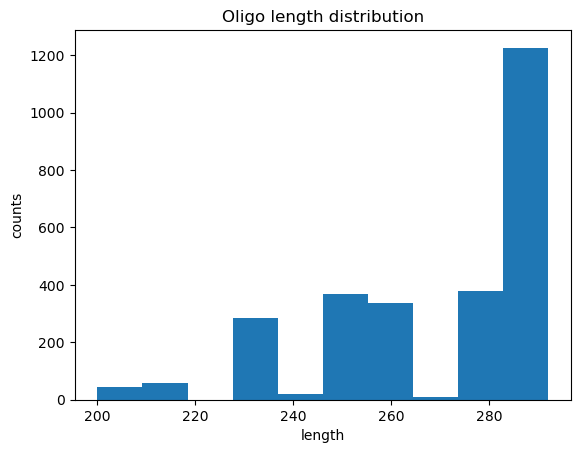

In [7]:
oligo_list = []
length_list = []

for num,subpool_dir in enumerate(glob.glob(PARENT_DIR + '/subpool_*_reverse_translate')):
    os.chdir(subpool_dir)
    order_file = glob.glob(subpool_dir+f'/{OWNER}_{PROJECT}_*_{CHIP_BATCH}')[0]
    fp = open(order_file,'r')
    for line in fp:
        oligo_list.append(line.rstrip())
        length_list.append(len(line.rstrip()))
    fp.close()
print(f'Total number of Oligo {len(oligo_list)}')
fp = open(PARENT_DIR + f'/{OWNER}_{PROJECT}_{CHIP_BATCH}','w')
fp.write('\n'.join(oligo_list))
fp.close()
print(f'Write into file {OWNER}_{PROJECT}_{CHIP_BATCH}.')

plt.hist(length_list)
plt.title('Oligo length distribution')
plt.xlabel('length')
plt.ylabel('counts')

## find other ways to deal with ChimeraForming pool
- if Chimera sequences are shorter than 120 aa, it is worth fixing.
- Impossible sequences are not worth fixing since they are just too long

In [8]:
chimera_seq,impossible_seq = [],[]
for num,chimera_f in enumerate(glob.glob(PARENT_DIR + '/subpool_*_reverse_translate/ChimeraForming_pool_*.tab')):
    if os.stat(chimera_f).st_size == 0:
        continue
    else:
        with open(chimera_f,'r') as fp:
            for line in fp:
                chimera_seq.append([line.rstrip().split()[0],line.rstrip().split()[1]])
print(f'Chimera seq {len(chimera_seq)}')

df_chimera = pd.DataFrame(chimera_seq,columns=['name','dna'])
df_chimera['note'] = 'chimera'
df_chimera['length'] = df_chimera['dna'].str.len()
df_chimera['protein_seq'] = ''
for j,row in df_chimera.iterrows():
    dna = Seq.Seq(row['dna'])
    df_chimera.loc[j,'protein_seq'] = str(dna.translate())
sns.displot(data = df_difficult,x='length',hue='note')
df_chimera.head()

Chimera seq 68


NameError: name 'Seq' is not defined

In [ ]:
def devide_list(total_num,group_num):
    indi_group_num = []
    group_ave = int(total_num/group_num)
    last_group_add = total_num%group_num
    while group_num > 1:
        indi_group_num.append(group_ave)
        group_num -= 1
    indi_group_num.append(group_ave+last_group_add)
    return indi_group_num

In [ ]:
# deal with chimera, impossible sequences are not worth to try
adaptor_list_for_chimera = [9,10] #put in the adaptor number
cmd_list = []
primer_dir = '/home/linnaan/software/LA_OligoOverlapOpt'
Tm = 65
MAX_OLIGO = 300
MAX_overlap = 45
chimera_dir = PARENT_DIR+f'/chimera_redo/'
os.makedirs(chimera_dir,exist_ok=True)
split_group = devide_list(len(df_chimera),len(adaptor_list_for_chimera))
print(split_group)
start = 0
for num,divident in enumerate(split_group):
    end = divident+start+1
    df_sel = df_chimera[start:end]
    with open(f'{chimera_dir}chimera_list{num}','w') as fp:
        fp.write('\n'.join([' '.join([str(row['name']),str(row['protein_seq']),str(row['dna'])]) for j,row in df_sel.iterrows()]))
    cmd = f'cd {chimera_dir} && python /home/linnaan/software/LA_OligoOverlapOpt/two_oligo_assembly.v2.py '+\
          f'-input_list {chimera_dir}chimera_list{num} ' + \
          f'-adaptor_number {adaptor_list_for_chimera[num]} '+\
          f'-min_melt_temp {Tm} -codontable_fname /home/linnaan/software/LA_OligoOverlapOpt/codontable.tab ' + \
          f'-adaptor_fname /home/linnaan/software/LA_OligoOverlapOpt/pool_adaptors_short_list.txt '+\
          f'-max_oligo_size {MAX_OLIGO} -maxoverlaplen {MAX_overlap}' 
    start += divident
    cmd_list.append(cmd)
fp = open(PARENT_DIR + '/chimera_break_oligo_cmd','w')
fp.write('\n'.join(cmd_list))
fp.close()

In [ ]:
CHIP_BATCH = '220801_Twist300nt_chimerafix'
OWNER = 'Linna_An'
PROJECT = 'CHD-PC' #name with something biofab can understand

total_num = 0
for num,order_file in enumerate(glob.glob(f'{PARENT_DIR}/chimera_redo/final_order_large_pool_[0-9]*.tab')):
    with open(order_file,'r') as fp:
        seq_list = [line.split()[-1].rstrip() for line in fp]
    print(f'total number of oligo: {len(seq_list)} from design {len(seq_list)/2}')
    with open(f'{PARENT_DIR}/chimera_redo/'+ '_'.join([OWNER,PROJECT,str(num),CHIP_BATCH]),'w') as fp:
        fp.write('\n'.join(seq_list))
    print('Order file ready!')
    total_num+= len(seq_list)
print(f'total oligo {total_num}')

## Concatenate your subpools
oligo_list = []
length_list = []
for num,order_file in enumerate(glob.glob(f'{PARENT_DIR}/chimera_redo/{OWNER}_{PROJECT}_*_{CHIP_BATCH}')):
    fp = open(order_file,'r')
    for line in fp:
        oligo_list.append(line.rstrip())
        length_list.append(len(line.rstrip()))
    fp.close()
print(f'Total number of Oligo {len(oligo_list)}')
with open(PARENT_DIR + f'/{OWNER}_{PROJECT}_{CHIP_BATCH}','w') as fp:
    fp.write('\n'.join(oligo_list))
print(f'Write into file {OWNER}_{PROJECT}_{CHIP_BATCH}.')

plt.hist(length_list)
plt.title('Oligo length distribution')
plt.xlabel('length')
plt.ylabel('counts')

## (Optional) check with David Feldman's scripts

In [ ]:
%matplotlib inline

In [ ]:
# adaptor_list = [15,16] #put in the adaptor number
# CHIP_BATCH = '211223_Twist300nt'
# OWNER = 'Linna_An'
# PROJECT = 'FOLAF2fix' #name with something biofab can understand
# OLIGO_CHECK = '/home/dfeldman/packages/postdoc_stable/scripts/app.sh'
OLIGO_CHECK = '/home/linnaan/software/DF_NGS/app.sh'
for num,adaptor in enumerate(adaptor_list):
    subpool_dir = PARENT_DIR + '/subpool_{}_reverse_translate'.format(num)
    final_order_file = subpool_dir+'/'+ '_'.join([OWNER,PROJECT,str(num),CHIP_BATCH])
    cmd = f'{OLIGO_CHECK} parse_overlap_oligos {final_order_file}'
    print(cmd)
#     os.chdir(subpool_dir)
#     result = subprocess.run([OLIGO_CHECK,'parse_overlap_oligos',final_order_file], stdout=subprocess.PIPE)

- Check out the results

In [ ]:
csv_list = glob.glob(PARENT_DIR + f'/subpool_*_reverse_translate/{OWNER}_{PROJECT}_[0-9]*_parsed.csv')
print(len(csv_list))

In [ ]:
print(PARENT_DIR)

In [ ]:
all_seq_df = []
for csv in csv_list:
    ind_df = pd.read_csv(csv)
    all_seq_df.append(ind_df)
all_df = pd.concat(all_seq_df)
all_df.to_csv(PARENT_DIR+'/parsed_seq_analysis')

In [ ]:
all_df